In [68]:
import pandas as pd
import numpy as np

In [69]:
file = pd.read_csv(r"C:\Users\MJ\Downloads\Generated_Admission_Management_Data.csv")

In [70]:
file.head(1)

,user_id,name,email,password,status,role,token,s_id,s_name,s_email,...,Higher_Secondary_Percentage,Entrance_Exam_Score,Previous_GPA,Number_of_Backlogs,Hackathon_Participation,Online_Courses_Completed,Number_of_Backlogs.1,Dropout_Risk,Final_Admission_Status,Scholarship_Granted
0,1,Tyler Silva,franklinrobert@yahoo.com,)%z40SInO+,1,2,4cc34e71-f673-4357-bf46-553bd9b24dae,1,Rebecca Estrada,grossgabriel@gmail.com,...,90.8,132.36,2.47,4.0,Yes,4.0,4.0,Low,Accepted,Yes


In [71]:
file.columns.tolist()

['user_id',
 'name',
 'email',
 'password',
 'status',
 'role',
 'token',
 's_id',
 's_name',
 's_email',
 's_mobile',
 's_photo',
 's_gender',
 's_category',
 's_edu_qua',
 's_parent_name',
 's_parent_mobile',
 's_parent_occupation',
 'c_id',
 'c_name',
 'c_fees',
 'c_duration',
 'ad_id',
 'ad_fees_status',
 'f_id',
 'amount_paid',
 'payment_date',
 'payment_method',
 'inq_id',
 'inq_query',
 'f_message',
 'department_id',
 'department_name',
 'head_of_department',
 'faculty_id',
 'faculty_name',
 'faculty_email',
 'faculty_phone',
 'document_id',
 'document_type',
 'upload_date',
 'file_path',
 'scholarship_id',
 'scholarship_name',
 'eligibility_criteria',
 'scholarship_amount',
 'award_id',
 'awarded_date',
 'application_id',
 'company_name',
 'application_date',
 'placement_status',
 'allocation_id',
 'job_position',
 'salary_package',
 'joining_date',
 'Volunteer_Experience',
 'Internship_Experience',
 'Online_Certifications_Count',
 'Sports_Achievements',
 'High_School_Percentag

In [72]:
file.drop(['user_id',
 'name',
 'email',
 'password','token',
 's_id',
 's_name',
 's_email',
 's_mobile',
 's_photo','s_parent_name',
 's_parent_mobile','c_id','ad_id',
 'f_id','payment_date','inq_id',
 'inq_query',
 'f_message',
 'department_id', 'head_of_department',
 'faculty_id',
 'faculty_name',
 'faculty_email',
 'faculty_phone',
 'document_id','upload_date',
 'file_path',
 'scholarship_id','eligibility_criteria','award_id',
 'awarded_date',
 'application_id',
 'company_name',
 'application_date','allocation_id','joining_date', 'Number_of_Backlogs.1'], axis = 1, inplace = True)

In [73]:
file.columns.tolist()

['status',
 'role',
 's_gender',
 's_category',
 's_edu_qua',
 's_parent_occupation',
 'c_name',
 'c_fees',
 'c_duration',
 'ad_fees_status',
 'amount_paid',
 'payment_method',
 'department_name',
 'document_type',
 'scholarship_name',
 'scholarship_amount',
 'placement_status',
 'job_position',
 'salary_package',
 'Volunteer_Experience',
 'Internship_Experience',
 'Online_Certifications_Count',
 'Sports_Achievements',
 'High_School_Percentage',
 'Higher_Secondary_Percentage',
 'Entrance_Exam_Score',
 'Previous_GPA',
 'Number_of_Backlogs',
 'Hackathon_Participation',
 'Online_Courses_Completed',
 'Dropout_Risk',
 'Final_Admission_Status',
 'Scholarship_Granted']

In [74]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score

def classify_report(ytest, y_pred):
    cm = classification_report(ytest, y_pred)
    print('Classification Report: \n', cm)
    error_rate = 1 - accuracy_score(ytest, y_pred)
    print('Error Rate:', error_rate)
    print('Accuracy Score:', accuracy_score(ytest, y_pred))
    print('Kappa Score:', cohen_kappa_score(ytest, y_pred))

file = file.replace(['Yes', 'No',
                     'OBC', 'ST', 'SC', 'General',
                     'PhD', "Master's", 'High School', "Bachelor's",
                     'Engineer', 'Business', 'Doctor', 'Other','Teacher',
                     'Electronics', 'Computer Science','Civil', 'Biotech','Mechanical', 
                     '2 Years', '3 Years', '4 Years',
                     'Debit Card', 'UPI', 'Net Banking', 'Credit Card',
                     'Commerce', 'Science', 'Engineering', 'Arts',
                     'ID Proof', 'Resume', '4', 'Transcript', 
                     'Sports Quota', 'Merit Scholarship', 'Need-Based',
                    'Software Engineer', 'Intern', 'Data Analyst', 'Manager', 
                     'Low', 'High','Medium',
                     'Rejected', 'Accepted', 'Waitlisted'], 
                    [1, 2, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 1, 2, 3])

def apply_years(salary_package):
    number, package = salary_package.split(' ')
    return int(number)

file['salary_package'] = file['salary_package'].apply(apply_years)



In [76]:
def feesData(fees):
    if 0 < fees <= 100000:
        return 1
    elif 100000 < fees <= 150000:
        return 2
    elif 150000 < fees <= 3000000:
        return 3
    elif 3000000 < fees <= 5000000:
        return 5
    else:
        return 0  # Handles out-of-range values

file['c_fees'] = file['c_fees'].apply(feesData)

def amount_paid(amt):
    if 0 < amt <= 10000:
        return 1
    elif 10000 < amt <= 80000:
        return 2
    elif 80000 < amt <= 150000:
        return 3
    elif 150000 < amt <= 10000000:
        return 5
    else:
        return 0  # Handles out-of-range values

file['amount_paid'] = file['amount_paid'].apply(amount_paid)


In [38]:
file.iloc[0:50, 15:]
# file['amount_paid'].max()

,scholarship_amount,placement_status,job_position,salary_package,Volunteer_Experience,Internship_Experience,Online_Certifications_Count,Sports_Achievements,High_School_Percentage,Higher_Secondary_Percentage,Entrance_Exam_Score,Previous_GPA,Number_of_Backlogs,Hackathon_Participation,Online_Courses_Completed,Dropout_Risk,Final_Admission_Status,Scholarship_Granted
0,500000,2,2,100,1.0,2.0,5.0,2.0,94.22,90.80,132.36,2.47,4.0,1.0,4.0,1.0,2.0,1.0
1,500000,0,1,100,1.0,1.0,NaN,1.0,50.64,89.21,87.67,2.61,5.0,2.0,5.0,1.0,1.0,1.0
2,42852,2,1,100,2.0,1.0,1.0,2.0,70.45,62.32,174.53,2.69,5.0,2.0,17.0,2.0,3.0,1.0
3,18144,2,2,6,2.0,2.0,5.0,1.0,86.44,51.58,28.40,3.76,2.0,2.0,8.0,2.0,2.0,1.0
4,37457,1,4,100,2.0,1.0,NaN,1.0,68.68,76.55,97.62,2.87,3.0,1.0,7.0,2.0,1.0,1.0
5,500000,0,1,8,1.0,2.0,4.0,1.0,95.45,50.14,27.46,2.58,1.0,2.0,12.0,3.0,2.0,1.0
6,28896,0,1,9,1.0,1.0,0.0,2.0,59.83,76.37,124.67,2.63,5.0,1.0,19.0,1.0,3.0,1.0
7,500000,0,4,3,1.0,1.0,7.0,2.0,91.54,75.41,44.80,3.89,4.0,1.0,11.0,3.0,2.0,1.0
8,500000,1,1,7,1.0,2.0,8.0,2.0,92.32,52.40,60.54,2.22,1.0,2.0,9.0,3.0,2.0,1.0
9,10225,1,1,9,2.0,1.0,7.0,2.0,96.77,51.18,47.81,3.78,2.0,1.0,0.0,1.0,2.0,1.0


In [77]:
file['Volunteer_Experience'].value_counts()

Volunteer_Experience
2.0    158
1.0    141
Name: count, dtype: int64

In [78]:
len(file.columns)

33

In [80]:
mean_Online_Certifications_Count = file['Online_Certifications_Count'].mean()
file['Online_Certifications_Count'].fillna(mean_Online_Certifications_Count, inplace=True)

# mean_Volunteer_Experience = file['Volunteer_Experience'].mean()
file['Volunteer_Experience'].fillna(2, inplace=True)

mean_Sports_Achievements = file['Sports_Achievements'].mean()
file['Sports_Achievements'].fillna(mean_Sports_Achievements, inplace=True)

mean_High_School_Percentage = file['High_School_Percentage'].mean()
file['High_School_Percentage'].fillna(mean_High_School_Percentage, inplace=True)

mean_Higher_Secondary_Percentage = file['Higher_Secondary_Percentage'].mean()
file['Higher_Secondary_Percentage'].fillna(mean_Higher_Secondary_Percentage, inplace=True)

mean_Internship_Experience = file['Internship_Experience'].mean()
file['Internship_Experience'].fillna(mean_Internship_Experience, inplace=True)

mean_Entrance_Exam_Score = file['Entrance_Exam_Score'].mean()
file['Entrance_Exam_Score'].fillna(mean_Entrance_Exam_Score, inplace=True)

mean_Previous_GPA = file['Previous_GPA'].mean()
file['Previous_GPA'].fillna(mean_Previous_GPA, inplace=True)

mean_Hackathon_Participation = file['Hackathon_Participation'].mean()
file['Hackathon_Participation'].fillna(mean_Hackathon_Participation, inplace=True)

mean_Online_Courses_Completed = file['Online_Courses_Completed'].mean()
file['Online_Courses_Completed'].fillna(mean_Online_Courses_Completed, inplace=True)

mean_Dropout_Risk = file['Dropout_Risk'].mean()
file['Dropout_Risk'].fillna(mean_Dropout_Risk, inplace=True)

mean_Final_Admission_Status = file['Final_Admission_Status'].mean()
file['Final_Admission_Status'].fillna(mean_Final_Admission_Status, inplace=True)

mean_Scholarship_Granted = file['Scholarship_Granted'].mean()
file['Scholarship_Granted'].fillna(mean_Scholarship_Granted, inplace=True)

mean_Number_of_Backlogs = file['Number_of_Backlogs'].mean()
file['Number_of_Backlogs'].fillna(mean_Number_of_Backlogs, inplace=True)

print(file.isnull().sum())

status                         0
role                           0
s_gender                       0
s_category                     0
s_edu_qua                      0
s_parent_occupation            0
c_name                         0
c_fees                         0
c_duration                     0
ad_fees_status                 0
amount_paid                    0
payment_method                 0
department_name                0
document_type                  0
scholarship_name               0
scholarship_amount             0
placement_status               0
job_position                   0
salary_package                 0
Volunteer_Experience           0
Internship_Experience          0
Online_Certifications_Count    0
Sports_Achievements            0
High_School_Percentage         0
Higher_Secondary_Percentage    0
Entrance_Exam_Score            0
Previous_GPA                   0
Number_of_Backlogs             0
Hackathon_Participation        0
Online_Courses_Completed       0
Dropout_Ri

In [81]:
from sklearn.model_selection import train_test_split

x = file.iloc[:, :14].values
y = file.iloc[:, 19].values

xtrain , xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [82]:
# print(ytest.unique())  
ytest = ytest.astype(int) # Check first 5 predicted values

In [83]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(xtrain, ytrain)

y_pred_gnb = gnb.predict(xtest)

classify_report(ytest, y_pred_gnb)

Classification Report: 
               precision    recall  f1-score   support

           1       0.44      0.42      0.43        26
           2       0.57      0.59      0.58        34

    accuracy                           0.52        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.51      0.52      0.52        60

Error Rate: 0.4833333333333333
Accuracy Score: 0.5166666666666667
Kappa Score: 0.011363636363636354


In [84]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(xtrain, ytrain)

y_pred_knn = knn.predict(xtest)

classify_report(ytest, y_pred_knn)

Classification Report: 
               precision    recall  f1-score   support

           1       0.50      0.54      0.52        26
           2       0.62      0.59      0.61        34

    accuracy                           0.57        60
   macro avg       0.56      0.56      0.56        60
weighted avg       0.57      0.57      0.57        60

Error Rate: 0.43333333333333335
Accuracy Score: 0.5666666666666667
Kappa Score: 0.12556053811659196


In [85]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 5)

rfc.fit(xtrain, ytrain)

y_pred_rfc = rfc.predict(xtest)

classify_report(ytest, y_pred_rfc)

Classification Report: 
               precision    recall  f1-score   support

           1       0.41      0.46      0.44        26
           2       0.55      0.50      0.52        34

    accuracy                           0.48        60
   macro avg       0.48      0.48      0.48        60
weighted avg       0.49      0.48      0.49        60

Error Rate: 0.5166666666666666
Accuracy Score: 0.48333333333333334
Kappa Score: -0.0379464285714286


In [86]:
from sklearn import tree

dtc = tree.DecisionTreeClassifier()

dtc.fit(xtrain,ytrain)

y_pred_dtc = dtc.predict(xtest)

classify_report(ytest,y_pred_dtc)

Classification Report: 
               precision    recall  f1-score   support

           1       0.47      0.58      0.52        26
           2       0.61      0.50      0.55        34

    accuracy                           0.53        60
   macro avg       0.54      0.54      0.53        60
weighted avg       0.55      0.53      0.53        60

Error Rate: 0.4666666666666667
Accuracy Score: 0.5333333333333333
Kappa Score: 0.07488986784140961


In [87]:
from sklearn.svm import SVC

svclassifier = SVC()

svclassifier.fit(xtrain, ytrain)

y_pred_svm = svclassifier.predict(xtest)

classify_report(ytest,y_pred_svm)

Classification Report: 
               precision    recall  f1-score   support

           1       0.39      0.35      0.37        26
           2       0.54      0.59      0.56        34

    accuracy                           0.48        60
   macro avg       0.47      0.47      0.47        60
weighted avg       0.48      0.48      0.48        60

Error Rate: 0.5166666666666666
Accuracy Score: 0.48333333333333334
Kappa Score: -0.06651376146788968


AUC value for Naive Bayes: 0.5056561085972852
AUC value for KNN: 0.5633484162895928
AUC value for Random Forest: 0.4807692307692307
AUC value for Decision Tree: 0.5056561085972852
AUC value for Support Vector Machine: 0.5056561085972852


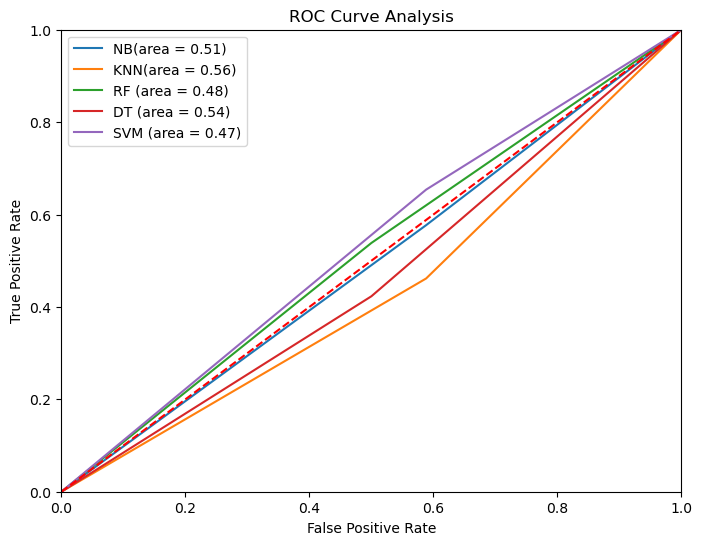

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,roc_auc_score

fpr,tpr,thresholds = roc_curve(ytest,y_pred_gnb,pos_label= 1,drop_intermediate = False)
fpr1,tpr1,thresholds1 = roc_curve(ytest,y_pred_knn,pos_label=1,drop_intermediate = False)
fpr2,tpr2,thresholds2 = roc_curve(ytest,y_pred_rfc,pos_label=1,drop_intermediate = False)
fpr3,tpr3,thresholds3 =roc_curve(ytest,y_pred_dtc ,pos_label=1,drop_intermediate = False)
fpr4,tpr4,thresholds4 = roc_curve(ytest,y_pred_svm,pos_label=1,drop_intermediate = False)
auc_score_nb = roc_auc_score(ytest,y_pred_gnb)
auc_score_knn = roc_auc_score(ytest,y_pred_knn)
auc_score_rfc = roc_auc_score(ytest,y_pred_rfc)
auc_score_dtc= roc_auc_score(ytest,y_pred_dtc)
auc_score_svm= roc_auc_score(ytest,y_pred_svm)
print("AUC value for Naive Bayes:",auc_score_nb)
print("AUC value for KNN:",auc_score_knn)
print("AUC value for Random Forest:",auc_score_rfc)
print("AUC value for Decision Tree:",auc_score_nb)
print("AUC value for Support Vector Machine:",auc_score_nb)
fig = plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label='NB(area = %0.2f)' %auc_score_nb)
plt.plot(fpr1,tpr1,label='KNN(area = %0.2f)' %auc_score_knn)
plt.plot(fpr2,tpr2,label='RF (area = %0.2f)' %auc_score_rfc)
plt.plot(fpr3,tpr3,label='DT (area = %0.2f)' %auc_score_dtc)
plt.plot(fpr4,tpr4,label='SVM (area = %0.2f)' %auc_score_svm)
plt.legend(loc = 'best')
plt.plot([0, 1], [0, 1],'r--')
#Setting X limit of x-axis
plt.xlim([0.0, 1.0])
#Setting Y limit of y-axis
plt.ylim([0.0, 1.0])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve Analysis')
plt.show()

In [89]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, random_state = None, shuffle = False)
kf.get_n_splits(x, y)

for train_index, test_index in kf.split(x, y):
    print("TRAIN:", train_index, "TEST:", test_index)
    xtrain, xtest = x[train_index], x[test_index]
    ytrain, ytest = y[train_index], y[test_index]

TRAIN: [ 30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263
 264 265 266 267 268 269 270 271 272 273 274

In [ ]:
# K Fold 

In [93]:
# Simple Random Forest Classifier

rfc = RandomForestClassifier(n_estimators=10)
rfc.fit(xtrain, ytrain)
y_pred_rfc = rfc.predict(xtest)

cm = confusion_matrix(ytest, y_pred_rfc)

print("Confusion Matrix:\n", cm)
error_rate = 1 - accuracy_score(ytest, y_pred_rfc)
print("Classification Report:\n")
print(classification_report(ytest, y_pred_rfc))
print('Accuracy:\n', accuracy_score(ytest, y_pred_rfc))
print("Error Rate: \n",error_rate )
print("Kappa Score: \n", cohen_kappa_score(ytest, y_pred_rfc))

Confusion Matrix:
 [[11  3]
 [12  4]]
Classification Report:

              precision    recall  f1-score   support

         1.0       0.48      0.79      0.59        14
         2.0       0.57      0.25      0.35        16

    accuracy                           0.50        30
   macro avg       0.52      0.52      0.47        30
weighted avg       0.53      0.50      0.46        30

Accuracy:
 0.5
Error Rate: 
 0.5
Kappa Score: 
 0.03433476394849799


In [101]:
# Creating KFold Cross Validation with RFC

from sklearn.model_selection import KFold

kf = KFold(n_splits=10, random_state=None, shuffle=False)
kf.get_n_splits(x, y)

i = 1
for train_index, test_index in kf.split(x, y):
    # print('train:', train_index, 'test:', test_index)
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print('----------')
    print('Split No:', i)
    print('----------')
    i+=1

    # Applying RFC here
    rfc = RandomForestClassifier(n_estimators=10)
    rfc.fit(x_train, y_train)
    y_pred_rfc = rfc.predict(x_test)

    classify_report(y_test, y_pred_rfc)

----------
Split No: 1
----------
Classification Report: 
               precision    recall  f1-score   support

         1.0       0.69      0.53      0.60        17
         2.0       0.53      0.69      0.60        13

    accuracy                           0.60        30
   macro avg       0.61      0.61      0.60        30
weighted avg       0.62      0.60      0.60        30

Error Rate: 0.4
Accuracy Score: 0.6
Kappa Score: 0.2139737991266375
----------
Split No: 2
----------
Classification Report: 
               precision    recall  f1-score   support

         1.0       0.29      0.50      0.37        10
         2.0       0.62      0.40      0.48        20

    accuracy                           0.43        30
   macro avg       0.45      0.45      0.43        30
weighted avg       0.51      0.43      0.45        30

Error Rate: 0.5666666666666667
Accuracy Score: 0.43333333333333335
Kappa Score: -0.0851063829787233
----------
Split No: 3
----------
Classification Report: 
  

In [106]:
# Using resample for bootstrap sampling and resampling the class with RFC

from sklearn.utils import resample

x_resample, y_resample = resample(x, y, replace=True, n_samples=None, random_state=0)

x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.3, random_state=0)

rfc = RandomForestClassifier(n_estimators=10)
rfc.fit(x_train, y_train)
y_pred_rfc = rfc.predict(x_test)

classify_report(y_test, y_pred_rfc)

Classification Report: 
               precision    recall  f1-score   support

         1.0       0.68      0.67      0.67        45
         2.0       0.67      0.69      0.68        45

    accuracy                           0.68        90
   macro avg       0.68      0.68      0.68        90
weighted avg       0.68      0.68      0.68        90

Error Rate: 0.3222222222222222
Accuracy Score: 0.6777777777777778
Kappa Score: 0.3555555555555555


In [107]:
# decision tree model creation
knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(xtrain,ytrain)

y_pred_knn = knn.predict(xtest)

classify_report(ytest,y_pred_knn)

Classification Report: 
               precision    recall  f1-score   support

         1.0       0.56      0.64      0.60        14
         2.0       0.64      0.56      0.60        16

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.60        30
weighted avg       0.61      0.60      0.60        30

Error Rate: 0.4
Accuracy Score: 0.6
Kappa Score: 0.20353982300884954


In [112]:
# Linear Discriminative Analysis using KNeighborsClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components = None)
xtrain = lda.fit_transform(xtrain, ytrain)
xtest = lda.transform(xtest)
# print(xtest)

print('Original Features:', x.shape[1])
print('Reduced number of Features:', xtrain.shape[1])

print('Variance Ratio:', lda.explained_variance_ratio_)

Original Features: 14
Reduced number of Features: 1
Variance Ratio: [1.]


In [113]:
#Prediction using LDA
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(xtrain,ytrain)

y_pred_knn = knn.predict(xtest)

classify_report(ytest,y_pred_knn)

Classification Report: 
               precision    recall  f1-score   support

         1.0       0.56      0.71      0.63        14
         2.0       0.67      0.50      0.57        16

    accuracy                           0.60        30
   macro avg       0.61      0.61      0.60        30
weighted avg       0.61      0.60      0.60        30

Error Rate: 0.4
Accuracy Score: 0.6
Kappa Score: 0.21052631578947367


In [114]:
# Using PCA
from sklearn.decomposition import PCA

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 0)

pca = PCA(n_components = 0.99)
print('Original Components:', xtrain.shape[1])
print('Original test features:', xtest.shape[1])

xtrain = pca.fit_transform(xtrain)
xtest = pca.transform(xtest)

print('Reduced number of features:', xtrain.shape[1])
print('Reduced number of testing features:', xtest.shape[1])

Original Components: 14
Original test features: 14
Reduced number of features: 14
Reduced number of testing features: 14


In [115]:
#Prediction using PCA

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(xtrain,ytrain)

y_pred_knn = knn.predict(xtest)

classify_report(ytest,y_pred_knn)

Classification Report: 
               precision    recall  f1-score   support

         1.0       0.49      0.69      0.57        26
         2.0       0.65      0.44      0.53        34

    accuracy                           0.55        60
   macro avg       0.57      0.57      0.55        60
weighted avg       0.58      0.55      0.55        60

Error Rate: 0.44999999999999996
Accuracy Score: 0.55
Kappa Score: 0.12715517241379304


In [118]:
from sklearn.decomposition import NMF

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 0)

nmf = NMF(n_components=2, init = 'random', random_state=0)
xtrain = nmf.fit_transform(xtrain)
xtest = nmf.transform(xtest)

print('Features:', xtrain.shape[1])
print('Test:', xtest.shape[1])


Features: 2
Test: 2


In [120]:
#Prediction using NMF

knn.fit(xtrain,ytrain)

y_pred_knn = knn.predict(xtest)

classify_report(ytest,y_pred_knn)

Classification Report: 
               precision    recall  f1-score   support

         1.0       0.43      0.58      0.49        26
         2.0       0.56      0.41      0.47        34

    accuracy                           0.48        60
   macro avg       0.49      0.49      0.48        60
weighted avg       0.50      0.48      0.48        60

Error Rate: 0.5166666666666666
Accuracy Score: 0.48333333333333334
Kappa Score: -0.010869565217391353


In [121]:
# Regression

In [156]:
from sklearn.model_selection import train_test_split

# file.columns.get_loc('Online_Certifications_Count')
x = file.iloc[:, [7, 10, 15, 18, 29] + list(range(21, 27))]
y = file.iloc[:, 27]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [159]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

regr = LinearRegression()
regr.fit(xtrain, ytrain)
y_pred_regr = regr.predict(xtest)
r2score = r2_score(ytest, y_pred_regr)
mae = mean_absolute_error(y_true=ytest, y_pred= y_pred_regr)
mse = mean_squared_error(y_true = ytest, y_pred = y_pred_regr)
rmse = mean_squared_error(y_true = ytest, y_pred = y_pred_regr, squared=False)

print('R-Squared Score:', r2score)
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)

R-Squared Score: -0.2728783269227919
MAE: 1.510850294468586
MSE: 3.262696481922911
RMSE: 1.8062935757852074


In [ ]:
from sklearn.liner_model import LogisticRegression